# RetinaCheck — Klasifikasi Retinopati Diabetik dengan Multi-Label Ordinal Sigmoid
**Proyek**: Statistics Essay Competition (SEC) SATRIA DATA
**Tema**: Transformasi Sistem Kesehatan Indonesia
**Dataset**: APTOS 2019 Blindness Detection
**Pendekatan**: Multi-Label Cumulative Sigmoid (ordinal-aware), 3 backbone dibandingkan
(EfficientNetB4, DenseNet121, ResNet50V2)

**Catatan metodologi**: Notebook ini menggunakan pendekatan *multi-label cumulative encoding*
untuk menangani sifat ordinal label Retinopati Diabetik (0=No_DR hingga 4=Proliferate_DR).
Alih-alih softmax 5-kelas independen, setiap kelas di-encode sebagai representasi cumulative
(misal label 3 → `[1,1,1,1,0]`), dilatih dengan 5 unit sigmoid + binary_crossentropy.
Pendekatan ini terbukti melalui eksperimen lebih baik dibanding softmax biasa untuk data ordinal,
dan konsisten dengan praktik pada kernel publik APTOS 2019 berperforma tinggi.

# 0. Cek Folder Input

In [1]:
import os

print('Apakah /kaggle/input/ ada?', os.path.exists('/kaggle/input/'))
print('\n=== Isi folder /kaggle/input/ ===')
if os.path.exists('/kaggle/input/'):
    items = os.listdir('/kaggle/input/')
    if len(items) == 0:
        print('  (KOSONG — tidak ada dataset yang ter-attach ke notebook ini)')
    else:
        for item in items:
            print(' ', item)
else:
    print('  Folder /kaggle/input/ tidak ditemukan sama sekali!')

Apakah /kaggle/input/ ada? True

=== Isi folder /kaggle/input/ ===
  competitions


# 1. Import Libraries & Setup

In [2]:
# ============================================================
# BAGIAN 1: Import semua library yang dibutuhkan
# ============================================================

# Reproducibility fix — WAJIB sebelum import TensorFlow
import os
os.environ['TF_DETERMINISTIC_OPS']   = '1'   # paksa operasi TF jadi deterministik
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'   # paksa cuDNN (GPU conv) jadi deterministik
os.environ['PYTHONHASHSEED']         = '42'  # konsistenkan hash Python

import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow dan Keras
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB4, DenseNet121, ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report, confusion_matrix

# ============================================================
# Set semua random seed untuk reproducibility
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()  # enforce determinism di level TF ops

# ============================================================
# Konfigurasi global
# ============================================================
IMG_SIZE    = 224          # Ukuran gambar input (224x224 piksel)
BATCH_SIZE  = 32           # Jumlah gambar per batch
NUM_CLASSES = 5            # Jumlah kelas (0-4)
EPOCHS      = 15           # Jumlah epoch training (unfreeze total, LR kecil)
LEARNING_RATE = 5e-5       # Learning rate kecil karena backbone langsung di-unfreeze

# Nama kelas untuk label
CLASS_NAMES = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

# ============================================================
# Path dataset Kaggle
# ============================================================
BASE_PATH = '/kaggle/input/competitions/aptos2019-blindness-detection/'

print('=== Struktur Folder Dataset ===')
for item in os.listdir(BASE_PATH):
    print(' ', item)

print(f'\nTensorFlow version : {tf.__version__}')
print(f'GPU tersedia       : {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'GPU devices        : {tf.config.list_physical_devices("GPU")}')

2026-06-23 12:53:41.830643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782219222.053224      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782219222.118105      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782219222.625621      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782219222.625660      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782219222.625662      58 computation_placer.cc:177] computation placer alr

=== Struktur Folder Dataset ===
  sample_submission.csv
  train_images
  train.csv
  test.csv
  test_images

TensorFlow version : 2.19.0
GPU tersedia       : True
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# 2. Load Dataset & EDA

In [3]:
# ============================================================
# BAGIAN 2A: Load CSV label dan tampilkan informasi dasar
# ============================================================
# CATATAN: dataset kompetisi resmi punya struktur FLAT (train_images/<id_code>.png),
# BUKAN per-folder kelas seperti dataset sebelumnya (colored_images/<NamaKelas>/...).

CSV_PATH = os.path.join(BASE_PATH, 'train.csv')
IMG_DIR  = os.path.join(BASE_PATH, 'train_images/')

# Load CSV ke DataFrame
df = pd.read_csv(CSV_PATH)

# Buat filepath dengan struktur flat: train_images/<id_code>.png
df['filepath'] = df['id_code'].apply(lambda x: os.path.join(IMG_DIR, x + '.png'))

# Validasi — pastikan file benar-benar ada
total   = len(df)
found   = df['filepath'].apply(os.path.exists).sum()
missing = total - found

print('=== 5 Baris Pertama Dataset ===')
display(df.head())

print(f'\nTotal gambar   : {total}')
print(f'File ditemukan : {found}')
print(f'File hilang    : {missing}')
print(f'\nContoh path: {df["filepath"].iloc[0]}')

=== 5 Baris Pertama Dataset ===


,id_code,diagnosis,filepath
0,000c1434d8d7,2,/kaggle/input/competitions/aptos2019-blindness...
1,001639a390f0,4,/kaggle/input/competitions/aptos2019-blindness...
2,0024cdab0c1e,1,/kaggle/input/competitions/aptos2019-blindness...
3,002c21358ce6,0,/kaggle/input/competitions/aptos2019-blindness...
4,005b95c28852,0,/kaggle/input/competitions/aptos2019-blindness...



Total gambar   : 3662
File ditemukan : 3662
File hilang    : 0

Contoh path: /kaggle/input/competitions/aptos2019-blindness-detection/train_images/000c1434d8d7.png


=== Distribusi Kelas ===
  Kelas 0 (No_DR               ):  1805 gambar (49.3%)
  Kelas 1 (Mild                ):   370 gambar (10.1%)
  Kelas 2 (Moderate            ):   999 gambar (27.3%)
  Kelas 3 (Severe              ):   193 gambar (5.3%)
  Kelas 4 (Proliferate_DR      ):   295 gambar (8.1%)

Total gambar       : 3662
Jumlah kelas       : 5
Rata-rata per kelas: 732 gambar


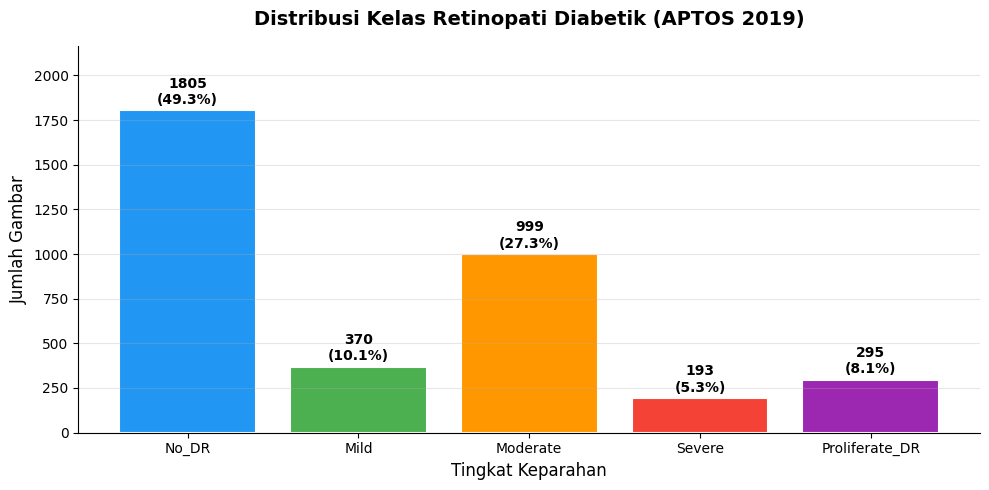

Dataset sangat imbalanced — kelas 0 (No_DR) mendominasi, kelas 3 (Severe) paling sedikit.


In [4]:
# ============================================================
# BAGIAN 2B: Statistik dasar dan distribusi kelas
# ============================================================

class_counts = df['diagnosis'].value_counts().sort_index()
class_pct    = class_counts / len(df) * 100

print('=== Distribusi Kelas ===')
for cls, count, pct in zip(CLASS_NAMES, class_counts, class_pct):
    print(f'  Kelas {CLASS_NAMES.index(cls)} ({cls:20s}): {count:5d} gambar ({pct:.1f}%)')

print(f'\nTotal gambar       : {len(df)}')
print(f'Jumlah kelas       : {NUM_CLASSES}')
print(f'Rata-rata per kelas: {len(df)/NUM_CLASSES:.0f} gambar')

# Visualisasi distribusi kelas dengan bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
bars = ax.bar(CLASS_NAMES, class_counts.values, color=colors, edgecolor='white', linewidth=1.5)

for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Distribusi Kelas Retinopati Diabetik (APTOS 2019)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tingkat Keparahan', fontsize=12)
ax.set_ylabel('Jumlah Gambar', fontsize=12)
ax.set_ylim(0, max(class_counts.values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dataset sangat imbalanced — kelas 0 (No_DR) mendominasi, kelas 3 (Severe) paling sedikit.')

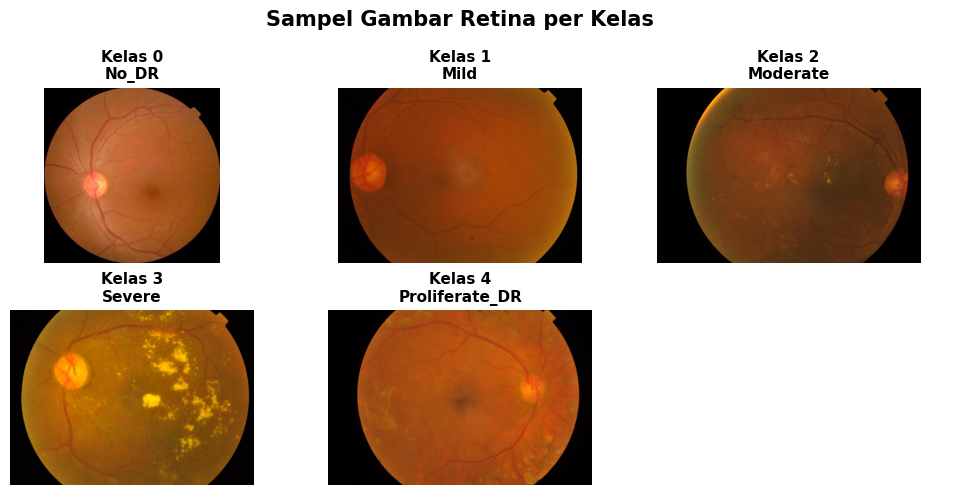

In [5]:
# ============================================================
# BAGIAN 2C: Tampilkan 1 sampel gambar per kelas (5 gambar)
# Layout: Baris 1 (3 gambar), Baris 2 (2 gambar)
# ============================================================

# Mengubah ukuran grid menjadi 2 baris dan 3 kolom
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
fig.suptitle('Sampel Gambar Retina per Kelas', fontsize=15, fontweight='bold')

# Meratakan (flatten) matriks axes menjadi 1D array agar mudah di-iterasi
axes_flat = axes.flatten()

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes_flat[cls_idx]
    
    sample_row = df[df['diagnosis'] == cls_idx].iloc[0]
    img_path   = sample_row['filepath']

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(f'Kelas {cls_idx}\n{cls_name}', fontsize=11, fontweight='bold')
    ax.axis('off')

# Menyembunyikan slot/axis terakhir (indeks ke-5) yang tidak terpakai
axes_flat[-1].axis('off')

plt.tight_layout()
plt.savefig('sampel_gambar_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Pre-processing & Data Splitting

In [6]:
# ============================================================
# BAGIAN 3A: Stratified Split — Train / Validation / Test
# ============================================================

labels = df['diagnosis'].values

# Langkah 1: Pisahkan 70% train dari 30% sisanya (stratified)
df_train, df_temp = train_test_split(
    df, test_size=0.30, stratify=labels, random_state=SEED
)

# Langkah 2: Dari 30% sisa, bagi 50/50 -> 15% validation + 15% test
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp['diagnosis'].values, random_state=SEED
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print('=== Hasil Data Splitting ===')
print(f'Train set      : {len(df_train):5d} gambar ({len(df_train)/len(df)*100:.1f}%)')
print(f'Validation set : {len(df_val):5d} gambar ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test set       : {len(df_test):5d} gambar ({len(df_test)/len(df)*100:.1f}%)')
print(f'Total          : {len(df_train)+len(df_val)+len(df_test):5d} gambar')

print('\n=== Distribusi Kelas per Split ===')
for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    counts = split_df['diagnosis'].value_counts().sort_index().values
    pcts   = counts / len(split_df) * 100
    print(f'{split_name:5s}: {[f"{c}({p:.0f}%)" for c, p in zip(counts, pcts)]}')

# Langkah 3: Cek variasi ukuran gambar asli (sebelum resize)
sample_paths = df['filepath'].iloc[:20].tolist()

print('Ukuran gambar asli (sample 20 gambar pertama):')
for p in sample_paths[:10]:
    img = cv2.imread(p)
    print(f'  {os.path.basename(p):20s}: {img.shape}')

=== Hasil Data Splitting ===
Train set      :  2563 gambar (70.0%)
Validation set :   549 gambar (15.0%)
Test set       :   550 gambar (15.0%)
Total          :  3662 gambar

=== Distribusi Kelas per Split ===
Train: ['1263(49%)', '259(10%)', '699(27%)', '135(5%)', '207(8%)']
Val  : ['271(49%)', '55(10%)', '150(27%)', '29(5%)', '44(8%)']
Test : ['271(49%)', '56(10%)', '150(27%)', '29(5%)', '44(8%)']
Ukuran gambar asli (sample 20 gambar pertama):
  000c1434d8d7.png    : (2136, 3216, 3)
  001639a390f0.png    : (2136, 3216, 3)
  0024cdab0c1e.png    : (1736, 2416, 3)
  002c21358ce6.png    : (1050, 1050, 3)
  005b95c28852.png    : (1536, 2048, 3)
  0083ee8054ee.png    : (2588, 3388, 3)
  0097f532ac9f.png    : (1958, 2588, 3)
  00a8624548a9.png    : (2136, 3216, 3)
  00b74780d31d.png    : (1958, 2588, 3)
  00cb6555d108.png    : (1736, 2416, 3)


Sample path : /kaggle/input/competitions/aptos2019-blindness-detection/train_images/38f1901f214a.png
File exists : True

Shape gambar hasil preprocessing : (224, 224, 3)
Range piksel                     : [6.0, 255.0]  (skala [0,255])


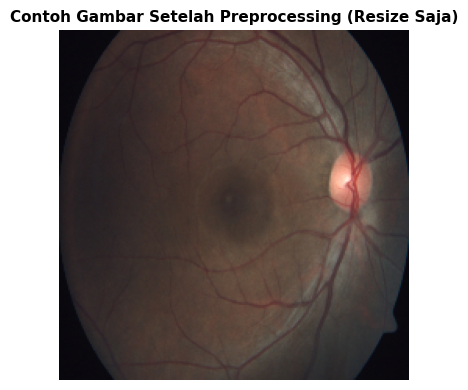

In [7]:
# ============================================================
# BAGIAN 3B: Preprocessing gambar — TANPA CLAHE
# ============================================================
# Berdasarkan eksperimen perbandingan dengan kernel referensi (publik, high-score),
# CLAHE TIDAK dipakai. Pretrained ImageNet weights dilatih di gambar natural tanpa
# histogram equalization khusus, dan CLAHE terbukti tidak membantu (bahkan
# berpotensi mendistorsi fitur low-level yang sudah dipelajari backbone).
# Preprocessing di sini hanya resize -- rescaling akhir (preprocess_input khusus
# per arsitektur) dilakukan di dalam model masing-masing (lihat Bagian 4).

def load_and_preprocess(filepath, img_size=IMG_SIZE):
    """
    Load gambar dan resize saja (tanpa CLAHE).
    Output dalam skala [0, 255] sebagai float32 -- BELUM dinormalisasi.
    Normalisasi/rescaling akhir dilakukan oleh preprocess_input di dalam model.
    """
    img = cv2.imread(str(filepath))

    if img is None:
        raise FileNotFoundError(f'Gambar tidak ditemukan atau gagal dibaca: {filepath}')

    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32)   # skala tetap [0, 255]

    return img


# Verifikasi path & preprocessing pada satu gambar contoh
sample_path = df_train['filepath'].iloc[0]
print(f'Sample path : {sample_path}')
print(f'File exists : {os.path.exists(sample_path)}')

proc_img = load_and_preprocess(sample_path)
print(f'\nShape gambar hasil preprocessing : {proc_img.shape}')
print(f'Range piksel                     : [{proc_img.min():.1f}, {proc_img.max():.1f}]  (skala [0,255])')

plt.figure(figsize=(4, 4))
plt.imshow(proc_img.astype(np.uint8))
plt.title('Contoh Gambar Setelah Preprocessing (Resize Saja)', fontsize=11, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('preprocessing_demo.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# BAGIAN 3C: Fungsi konversi label — Multi-Label Cumulative Encoding
# ============================================================
# Pendekatan ordinal-aware: label diagnosis 0-4 diubah menjadi cumulative
# multi-label encoding. Misal diagnosis=3 (Severe) -> [1,1,1,1,0]
# artinya "severity >= No_DR DAN >= Mild DAN >= Moderate DAN >= Severe,
# TAPI BUKAN >= Proliferate_DR". Model dilatih sebagai 5 klasifikasi biner
# independen (sigmoid + binary_crossentropy), bukan softmax 5-kelas.
# Prediksi akhir dikonversi balik dengan menghitung berapa banyak sigmoid
# output yang >= threshold.

def to_cumulative_label(labels, num_classes=NUM_CLASSES):
    """
    Konversi label integer 0-4 menjadi cumulative multi-label.
    Contoh: label=3 -> [1,1,1,1,0]
    """
    n = len(labels)
    y_cum = np.zeros((n, num_classes), dtype=np.float32)
    for i, lbl in enumerate(labels):
        y_cum[i, :int(lbl) + 1] = 1.0
    return y_cum


def from_cumulative_pred(preds, threshold=0.5):
    """
    Konversi prediksi sigmoid [n, num_classes] balik ke single-label.
    Caranya: hitung berapa banyak output >= threshold.
    Contoh: [1, 1, 1, 0, 0] -> 3 nilai >= threshold -> label = 3 - 1 = 2
    Jika count=0 (semua sigmoid < threshold), fallback ke label 0.
    """
    counts = (preds >= threshold).sum(axis=1)
    labels = np.clip(counts - 1, 0, NUM_CLASSES - 1)
    return labels.astype(int)


# Verifikasi cepat fungsi encoding/decoding sebelum dipakai
_test_labels = np.array([0, 1, 2, 3, 4])
_test_enc    = to_cumulative_label(_test_labels)
_test_dec    = from_cumulative_pred(_test_enc)
print(f'Verifikasi encoding/decoding: {_test_labels.tolist()} -> {_test_dec.tolist()}')
assert (_test_labels == _test_dec).all(), 'Encoding/decoding tidak konsisten!'
print('Encoding/decoding terverifikasi benar.')
print(f'\nContoh encoding cumulative:')
for lbl, enc in zip(_test_labels, _test_enc):
    print(f'  Label {lbl} ({CLASS_NAMES[lbl]:15s}) -> {enc}')

Verifikasi encoding/decoding: [0, 1, 2, 3, 4] -> [0, 1, 2, 3, 4]
Encoding/decoding terverifikasi benar.

Contoh encoding cumulative:
  Label 0 (No_DR          ) -> [1. 0. 0. 0. 0.]
  Label 1 (Mild           ) -> [1. 1. 0. 0. 0.]
  Label 2 (Moderate       ) -> [1. 1. 1. 0. 0.]
  Label 3 (Severe         ) -> [1. 1. 1. 1. 0.]
  Label 4 (Proliferate_DR ) -> [1. 1. 1. 1. 1.]


# 4. Data Generator & Augmentation

In [9]:
# ============================================================
# BAGIAN 4: Data Generator dengan Augmentasi (Multi-Label)
# ============================================================
# Augmentasi: flip horizontal+vertikal dan zoom (TANPA rotasi ekstrem),
# konsisten dengan pendekatan kernel referensi berperforma tinggi.
# Gambar berskala [0, 255] -- rescaling khusus arsitektur (preprocess_input)
# dilakukan di dalam masing-masing model (Bagian 5).

def create_data_generator_multilabel(dataframe, augment=False, batch_size=BATCH_SIZE):
    """
    Buat tf.data.Dataset dari DataFrame dengan label cumulative multi-label.
    augment=True hanya untuk train set.
    """
    filepaths  = dataframe['filepath'].values
    labels     = dataframe['diagnosis'].values
    labels_cum = to_cumulative_label(labels, NUM_CLASSES)

    def load_image(filepath, label):
        """Load dan preprocess satu gambar via tf.py_function."""
        def _load(fp, lb):
            fp_str = fp.numpy().decode('utf-8')
            lb_np  = lb.numpy()
            img    = load_and_preprocess(fp_str)   # skala [0, 255] float32
            return img, lb_np.astype(np.float32)

        img, lbl = tf.py_function(
            func=_load,
            inp=[filepath, label],
            Tout=[tf.float32, tf.float32]
        )
        img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        lbl.set_shape([NUM_CLASSES])
        return img, lbl

    def augment_image(img, label):
        """Augmentasi: flip H+V dan zoom, menggunakan tf.image (aman untuk tf.data.map)."""
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)

        # Random zoom (+-15%) menggunakan resize + crop/pad
        zoom_factor = tf.random.uniform(shape=[], minval=0.85, maxval=1.15)
        new_size    = tf.cast(tf.cast(IMG_SIZE, tf.float32) * zoom_factor, tf.int32)
        img         = tf.image.resize(img, [new_size, new_size])
        img         = tf.image.resize_with_crop_or_pad(img, IMG_SIZE, IMG_SIZE)

        img = tf.clip_by_value(img, 0.0, 255.0)
        return img, label

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels_cum))
    if augment:
        dataset = dataset.shuffle(buffer_size=len(filepaths), seed=SEED)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


print('Fungsi create_data_generator_multilabel berhasil didefinisikan.')

Fungsi create_data_generator_multilabel berhasil didefinisikan.


# 5. Fungsi Helper — Build Model, Training, & Evaluasi

In [10]:
# ============================================================
# BAGIAN 5A: Fungsi pembuatan model Multi-Label Sigmoid
# ============================================================
# Arsitektur: Input ([0,255]) -> preprocess_input (khusus arsitektur)
#             -> Backbone (pretrained, TRAINABLE dari awal, TANPA freeze 2-fase)
#             -> GlobalAveragePooling2D -> Dropout(0.5) -> Dense(5, sigmoid)
#
# Backbone TIDAK di-freeze sama sekali (langsung fine-tune total dari awal
# dengan learning rate sangat kecil), sesuai pendekatan kernel referensi
# yang terbukti lebih baik dibanding strategi freeze-lalu-unfreeze 2-fase.

PREPROCESS_FN_MAP = {
    'EfficientNetB4': tf.keras.applications.efficientnet.preprocess_input,
    'DenseNet121'   : tf.keras.applications.densenet.preprocess_input,
    'ResNet50V2'    : tf.keras.applications.resnet_v2.preprocess_input,
}

BACKBONE_CLASS_MAP = {
    'EfficientNetB4': EfficientNetB4,
    'DenseNet121'   : DenseNet121,
    'ResNet50V2'    : ResNet50V2,
}


def build_multilabel_model(model_name, input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Bangun model multi-label sigmoid untuk satu arsitektur backbone.

    Args:
        model_name : salah satu dari 'EfficientNetB4', 'DenseNet121', 'ResNet50V2'

    Returns:
        model (Keras Model, sudah di-compile), backbone (objek backbone untuk Grad-CAM nanti)
    """
    tf.keras.backend.clear_session()

    backbone_class = BACKBONE_CLASS_MAP[model_name]
    preprocess_fn  = PREPROCESS_FN_MAP[model_name]

    backbone = backbone_class(weights='imagenet', include_top=False, input_shape=input_shape)
    backbone.trainable = True   # langsung trainable dari awal, TANPA freeze 2-fase

    inputs  = Input(shape=input_shape)
    x = preprocess_fn(inputs)               # rescaling khusus arsitektur (input awal [0,255])
    x = backbone(x, training=True)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)   # SIGMOID, bukan softmax

    model = Model(inputs, outputs, name=f'{model_name}_MultiLabel')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',     # BUKAN categorical_crossentropy
        metrics=['accuracy']
    )

    return model, backbone


def get_callbacks(model_name):
    """Buat callbacks standar: ModelCheckpoint, EarlyStopping, ReduceLROnPlateau."""
    return [
        ModelCheckpoint(filepath=f'best_{model_name}.h5', monitor='val_loss', save_best_only=True, verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ]


def plot_training_curve(history, model_name):
    """Plot kurva loss dan accuracy (binary, per-kolom sigmoid) per epoch."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training Curve — {model_name}', fontsize=14, fontweight='bold')

    ax1.plot(history.history['loss'],     label='Train Loss', color='#2196F3', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss',   color='#F44336', linewidth=2, linestyle='--')
    ax1.set_title('Loss per Epoch', fontsize=12)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Train Acc (binary, per-kolom)', color='#4CAF50', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Val Acc (binary, per-kolom)',   color='#FF9800', linewidth=2, linestyle='--')
    ax2.set_title('Binary Accuracy per Epoch\n(per-kolom sigmoid, BUKAN akurasi klasifikasi 5-kelas)', fontsize=11)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Binary Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'training_curve_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_multilabel_model(model, test_dataset, test_df, model_name, threshold=0.5):
    """
    Evaluasi model multi-label pada test set.
    PENTING: prediksi sigmoid mentah dikonversi balik ke single-label
    (via from_cumulative_pred) SEBELUM dihitung accuracy/F1/QWK/confusion matrix,
    karena metrik-metrik ini didefinisikan untuk klasifikasi single-label.
    """
    print(f'\n=== Evaluasi {model_name} pada Test Set ===')

    y_pred_sigmoid = model.predict(test_dataset, verbose=1)
    y_pred = from_cumulative_pred(y_pred_sigmoid, threshold=threshold)
    y_true = test_df['diagnosis'].values[:len(y_pred)]

    acc    = np.mean(y_pred == y_true)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    qwk    = cohen_kappa_score(y_true, y_pred, weights='quadratic')

    print(f'Accuracy (Test)  : {acc:.4f}')
    print(f'F1-Score (Macro) : {f1_mac:.4f}')
    print(f'QWK              : {qwk:.4f}')

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor='gray'
    )
    plt.title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.ylabel('Label Asli', fontsize=11)
    plt.xlabel('Prediksi Model', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'model_name': model_name,
        'accuracy'  : acc,
        'f1_macro'  : f1_mac,
        'qwk'       : qwk,
        'y_true'    : y_true,
        'y_pred'    : y_pred,
        'y_pred_sigmoid': y_pred_sigmoid
    }


print('Fungsi helper (build_multilabel_model, evaluate_multilabel_model, dll) berhasil didefinisikan.')

Fungsi helper (build_multilabel_model, evaluate_multilabel_model, dll) berhasil didefinisikan.


# 6. Model 1: EfficientNetB4 (Multi-Label Sigmoid)

In [11]:
# ============================================================
# Training EfficientNetB4 — Multi-Label Sigmoid
# ============================================================

print('='*60)
print('MODEL 1: EfficientNetB4 — Multi-Label Sigmoid')
print('='*60)

train_dataset_eff = create_data_generator_multilabel(df_train, augment=True,  batch_size=BATCH_SIZE)
val_dataset_eff   = create_data_generator_multilabel(df_val,   augment=False, batch_size=BATCH_SIZE)
test_dataset_eff  = create_data_generator_multilabel(df_test,  augment=False, batch_size=BATCH_SIZE)

model_eff, backbone_eff = build_multilabel_model('EfficientNetB4')

print(f'Total parameter        : {model_eff.count_params():,}')
print(f'Parameter dapat dilatih: {sum([tf.size(w).numpy() for w in model_eff.trainable_variables]):,}')

history_eff = model_eff.fit(
    train_dataset_eff,
    validation_data=val_dataset_eff,
    epochs=EPOCHS,
    callbacks=get_callbacks('efficientnetb4'),
    verbose=1
)

print('\nTraining EfficientNetB4 selesai!')

MODEL 1: EfficientNetB4 — Multi-Label Sigmoid


I0000 00:00:1782219248.436326      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782219248.442064      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameter        : 17,682,788
Parameter dapat dilatih: 17,557,581
Epoch 1/15


2026-06-23 12:54:14.451817: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_9}}
E0000 00:00:1782219320.625859      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB4_MultiLabel_1/efficientnetb4_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCH

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2991 - loss: 0.6097
Epoch 1: val_loss improved from None to 0.47881, saving model to best_efficientnetb4.h5


...


Epoch 3: finished saving model to best_efficientnetb4.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.6933 - loss: 0.1778 - val_accuracy: 0.7559 - val_loss: 0.1854 - learning_rate: 5.0000e-05
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7006 - loss: 0.1496
Epoch 4: val_loss improved from 0.18541 to 0.16092, saving model to best_efficientnetb4.h5



Epoch 4: finished saving model to best_efficientnetb4.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 354s 4s/step - accuracy: 0.7078 - loss: 0.1502 - val_accuracy: 0.7250 - val_loss: 0.1609 - learning_rate: 5.0000e-05
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7151 - loss: 0.1341
Epoch 5: val_loss did not improve from 0.16092
81/81 ━━━━━━━━━━━━━━━━━━━━ 353s 4s/step - accuracy: 0.7163 - loss: 0.1309 - val_accuracy: 0.7304 - val_loss: 0.1615 - learning_rate: 5.0000e-05
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7084 - loss: 0.1204
Epoch 6: val_loss improved from 0.16092 to 0.14311, saving model to best_efficientnetb4.h5



Epoch 6: finished saving model to best_efficientnetb4.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - accuracy: 0.7097 - loss: 0.1225 - val_accuracy: 0.7304 - val_loss: 0.1431 - learning_rate: 5.0000e-05
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6944 - loss: 0.1099
Epoch 7: val_loss improved from 0.14311 to 0.13997, saving model to best_efficientnetb4.h5



Epoch 7: finished saving model to best_efficientnetb4.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.7031 - loss: 0.1098 - val_accuracy: 0.6849 - val_loss: 0.1400 - learning_rate: 5.0000e-05
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7256 - loss: 0.1043
Epoch 8: val_loss improved from 0.13997 to 0.13455, saving model to best_efficientnetb4.h5



Epoch 8: finished saving model to best_efficientnetb4.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.7156 - loss: 0.1051 - val_accuracy: 0.6849 - val_loss: 0.1346 - learning_rate: 5.0000e-05
Epoch 9/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6967 - loss: 0.1014
Epoch 9: val_loss did not improve from 0.13455
81/81 ━━━━━━━━━━━━━━━━━━━━ 356s 4s/step - accuracy: 0.6957 - loss: 0.0951 - val_accuracy: 0.7122 - val_loss: 0.1497 - learning_rate: 5.0000e-05
Epoch 10/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6957 - loss: 0.0804
Epoch 10: val_loss did not improve from 0.13455
81/81 ━━━━━━━━━━━━━━━━━━━━ 357s 4s/step - accuracy: 0.6879 - loss: 0.0873 - val_accuracy: 0.6903 - val_loss: 0.1374 - learning_rate: 5.0000e-05
Epoch 11/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7028 - loss: 0.0809
Epoch 11: val_loss did not improve from 0.13455

Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
81/81 ━━━━━━━━━━━━━━━━━━━━ 357s 4s/ste

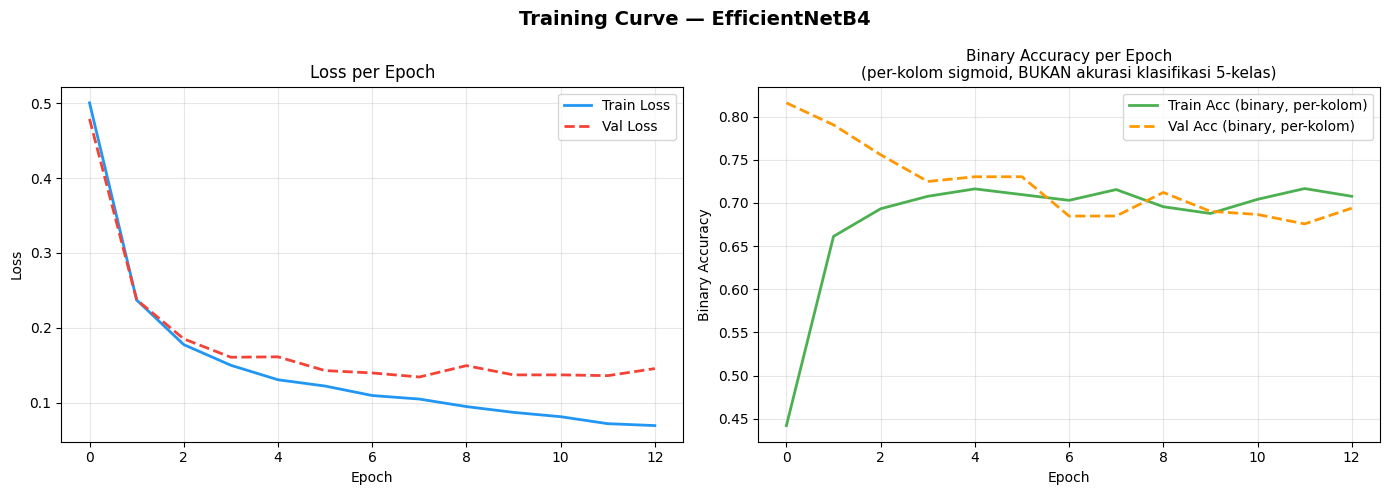


=== Evaluasi EfficientNetB4 pada Test Set ===
18/18 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step
Accuracy (Test)  : 0.8073
F1-Score (Macro) : 0.6298
QWK              : 0.8875

Classification Report:
                precision    recall  f1-score   support

         No_DR       0.97      0.98      0.97       271
          Mild       0.59      0.48      0.53        56
      Moderate       0.71      0.81      0.75       150
        Severe       0.36      0.34      0.35        29
Proliferate_DR       0.67      0.45      0.54        44

      accuracy                           0.81       550
     macro avg       0.66      0.61      0.63       550
  weighted avg       0.80      0.81      0.80       550



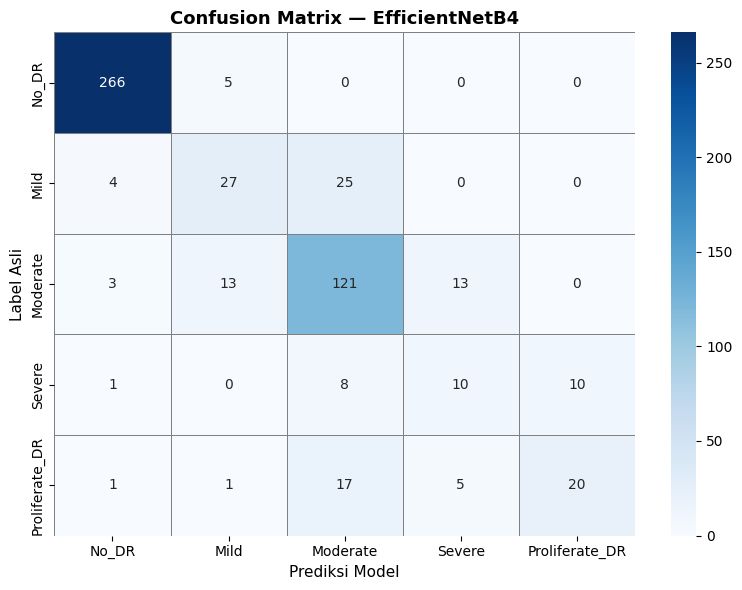

In [12]:
# Evaluasi EfficientNetB4
plot_training_curve(history_eff, 'EfficientNetB4')
results_eff = evaluate_multilabel_model(model_eff, test_dataset_eff, df_test, 'EfficientNetB4')

# 7. Model 2: DenseNet121 (Multi-Label Sigmoid)

In [13]:
# ============================================================
# Training DenseNet121 — Multi-Label Sigmoid
# ============================================================

print('='*60)
print('MODEL 2: DenseNet121 — Multi-Label Sigmoid')
print('='*60)

train_dataset_dense = create_data_generator_multilabel(df_train, augment=True,  batch_size=BATCH_SIZE)
val_dataset_dense   = create_data_generator_multilabel(df_val,   augment=False, batch_size=BATCH_SIZE)
test_dataset_dense  = create_data_generator_multilabel(df_test,  augment=False, batch_size=BATCH_SIZE)

model_dense, backbone_dense = build_multilabel_model('DenseNet121')

print(f'Total parameter        : {model_dense.count_params():,}')
print(f'Parameter dapat dilatih: {sum([tf.size(w).numpy() for w in model_dense.trainable_variables]):,}')

history_dense = model_dense.fit(
    train_dataset_dense,
    validation_data=val_dataset_dense,
    epochs=EPOCHS,
    callbacks=get_callbacks('densenet121'),
    verbose=1
)

print('\nTraining DenseNet121 selesai!')

MODEL 2: DenseNet121 — Multi-Label Sigmoid
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameter        : 7,042,629
Parameter dapat dilatih: 6,958,981
Epoch 1/15


2026-06-23 14:15:08.566322: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_9}}


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2821 - loss: 0.6882
Epoch 1: val_loss improved from None to 0.42015, saving model to best_densenet121.h5



Epoch 1: finished saving model to best_densenet121.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 418s 4s/step - accuracy: 0.4397 - loss: 0.5172 - val_accuracy: 0.6084 - val_loss: 0.4201 - learning_rate: 5.0000e-05
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6323 - loss: 0.2525
Epoch 2: val_loss improved from 0.42015 to 0.27226, saving model to best_densenet121.h5



Epoch 2: finished saving model to best_densenet121.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.6453 - loss: 0.2400 - val_accuracy: 0.7013 - val_loss: 0.2723 - learning_rate: 5.0000e-05
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6478 - loss: 0.1896
Epoch 3: val_loss improved from 0.27226 to 0.21146, saving model to best_densenet121.h5


...


Epoch 6: finished saving model to best_densenet121.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.6824 - loss: 0.1349 - val_accuracy: 0.6867 - val_loss: 0.1460 - learning_rate: 5.0000e-05
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6600 - loss: 0.1274
Epoch 7: val_loss improved from 0.14597 to 0.14045, saving model to best_densenet121.h5



Epoch 7: finished saving model to best_densenet121.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.6586 - loss: 0.1229 - val_accuracy: 0.6721 - val_loss: 0.1405 - learning_rate: 5.0000e-05
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6805 - loss: 0.1116
Epoch 8: val_loss improved from 0.14045 to 0.13391, saving model to best_densenet121.h5



Epoch 8: finished saving model to best_densenet121.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.6793 - loss: 0.1155 - val_accuracy: 0.6885 - val_loss: 0.1339 - learning_rate: 5.0000e-05
Epoch 9/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6788 - loss: 0.1146
Epoch 9: val_loss did not improve from 0.13391
81/81 ━━━━━━━━━━━━━━━━━━━━ 334s 4s/step - accuracy: 0.6789 - loss: 0.1086 - val_accuracy: 0.7814 - val_loss: 0.1716 - learning_rate: 5.0000e-05
Epoch 10/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6593 - loss: 0.0986
Epoch 10: val_loss improved from 0.13391 to 0.13244, saving model to best_densenet121.h5



Epoch 10: finished saving model to best_densenet121.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.6676 - loss: 0.1062 - val_accuracy: 0.7250 - val_loss: 0.1324 - learning_rate: 5.0000e-05
Epoch 11/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7129 - loss: 0.1002
Epoch 11: val_loss improved from 0.13244 to 0.12828, saving model to best_densenet121.h5



Epoch 11: finished saving model to best_densenet121.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.7085 - loss: 0.0995 - val_accuracy: 0.6976 - val_loss: 0.1283 - learning_rate: 5.0000e-05
Epoch 12/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6795 - loss: 0.0983
Epoch 12: val_loss did not improve from 0.12828
81/81 ━━━━━━━━━━━━━━━━━━━━ 340s 4s/step - accuracy: 0.6812 - loss: 0.0978 - val_accuracy: 0.8434 - val_loss: 0.1489 - learning_rate: 5.0000e-05
Epoch 13/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6650 - loss: 0.0851
Epoch 13: val_loss did not improve from 0.12828
81/81 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.6687 - loss: 0.0878 - val_accuracy: 0.7413 - val_loss: 0.1794 - learning_rate: 5.0000e-05
Epoch 14/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6538 - loss: 0.0899
Epoch 14: val_loss did not improve from 0.12828

Epoch 14: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
81/81 ━━━━━━━━━━━━━━━━━━━━ 345s 4s/ste

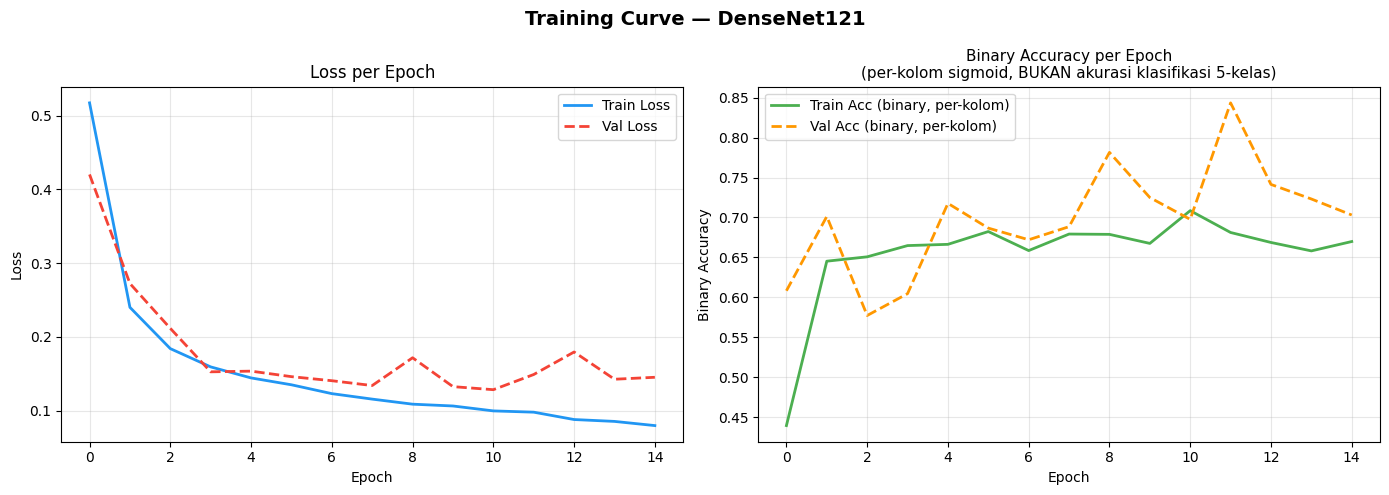


=== Evaluasi DenseNet121 pada Test Set ===
18/18 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step
Accuracy (Test)  : 0.7818
F1-Score (Macro) : 0.5846
QWK              : 0.8827

Classification Report:
                precision    recall  f1-score   support

         No_DR       0.96      0.97      0.97       271
          Mild       0.49      0.54      0.51        56
      Moderate       0.70      0.75      0.72       150
        Severe       0.28      0.28      0.28        29
Proliferate_DR       0.62      0.34      0.44        44

      accuracy                           0.78       550
     macro avg       0.61      0.58      0.58       550
  weighted avg       0.78      0.78      0.78       550



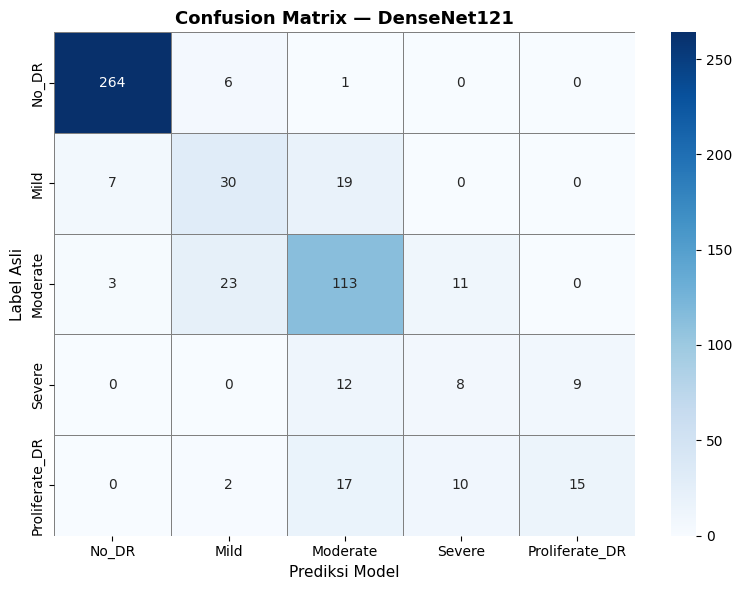

In [14]:
# Evaluasi DenseNet121
plot_training_curve(history_dense, 'DenseNet121')
results_dense = evaluate_multilabel_model(model_dense, test_dataset_dense, df_test, 'DenseNet121')

# 8. Model 3: ResNet50V2 (Multi-Label Sigmoid)

In [15]:
# ============================================================
# Training ResNet50V2 — Multi-Label Sigmoid
# ============================================================

print('='*60)
print('MODEL 3: ResNet50V2 — Multi-Label Sigmoid')
print('='*60)

train_dataset_res = create_data_generator_multilabel(df_train, augment=True,  batch_size=BATCH_SIZE)
val_dataset_res   = create_data_generator_multilabel(df_val,   augment=False, batch_size=BATCH_SIZE)
test_dataset_res  = create_data_generator_multilabel(df_test,  augment=False, batch_size=BATCH_SIZE)

model_res, backbone_res = build_multilabel_model('ResNet50V2')

print(f'Total parameter        : {model_res.count_params():,}')
print(f'Parameter dapat dilatih: {sum([tf.size(w).numpy() for w in model_res.trainable_variables]):,}')

history_res = model_res.fit(
    train_dataset_res,
    validation_data=val_dataset_res,
    epochs=EPOCHS,
    callbacks=get_callbacks('resnet50v2'),
    verbose=1
)

print('\nTraining ResNet50V2 selesai!')

MODEL 3: ResNet50V2 — Multi-Label Sigmoid
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameter        : 23,575,045
Parameter dapat dilatih: 23,529,605
Epoch 1/15


2026-06-23 15:42:22.666180: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_9}}


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5618 - loss: 0.4812
Epoch 1: val_loss improved from None to 0.40374, saving model to best_resnet50v2.h5



Epoch 1: finished saving model to best_resnet50v2.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 0.7546 - loss: 0.3311 - val_accuracy: 1.0000 - val_loss: 0.4037 - learning_rate: 5.0000e-05
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7941 - loss: 0.1781
Epoch 2: val_loss improved from 0.40374 to 0.21920, saving model to best_resnet50v2.h5



Epoch 2: finished saving model to best_resnet50v2.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - accuracy: 0.7835 - loss: 0.1758 - val_accuracy: 0.9763 - val_loss: 0.2192 - learning_rate: 5.0000e-05
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8344 - loss: 0.1512
Epoch 3: val_loss did not improve from 0.21920
81/81 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.8166 - loss: 0.1495 - val_accuracy: 0.9872 - val_loss: 0.2984 - learning_rate: 5.0000e-05
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8325 - loss: 0.1277
Epoch 4: val_loss improved from 0.21920 to 0.15892, saving model to best_resnet50v2.h5



Epoch 4: finished saving model to best_resnet50v2.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - accuracy: 0.8053 - loss: 0.1306 - val_accuracy: 0.7942 - val_loss: 0.1589 - learning_rate: 5.0000e-05
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8342 - loss: 0.1117
Epoch 5: val_loss did not improve from 0.15892
81/81 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.8131 - loss: 0.1163 - val_accuracy: 0.9126 - val_loss: 0.1840 - learning_rate: 5.0000e-05
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8291 - loss: 0.1103
Epoch 6: val_loss did not improve from 0.15892
81/81 ━━━━━━━━━━━━━━━━━━━━ 328s 4s/step - accuracy: 0.8139 - loss: 0.1127 - val_accuracy: 0.8634 - val_loss: 0.1762 - learning_rate: 5.0000e-05
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7582 - loss: 0.1084
Epoch 7: val_loss did not improve from 0.15892

Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
81/81 ━━━━━━━━━━━━━━━━━━━━ 323s 4s/step - accur


Epoch 8: finished saving model to best_resnet50v2.h5
81/81 ━━━━━━━━━━━━━━━━━━━━ 325s 4s/step - accuracy: 0.7913 - loss: 0.0862 - val_accuracy: 0.8069 - val_loss: 0.1473 - learning_rate: 2.5000e-05
Epoch 9/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7794 - loss: 0.0795
Epoch 9: val_loss did not improve from 0.14726
81/81 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.7913 - loss: 0.0759 - val_accuracy: 0.7887 - val_loss: 0.1640 - learning_rate: 2.5000e-05
Epoch 10/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7719 - loss: 0.0637
Epoch 10: val_loss did not improve from 0.14726
81/81 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.7686 - loss: 0.0702 - val_accuracy: 0.8069 - val_loss: 0.1693 - learning_rate: 2.5000e-05
Epoch 11/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7745 - loss: 0.0624
Epoch 11: val_loss did not improve from 0.14726

Epoch 11: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
81/81 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - 

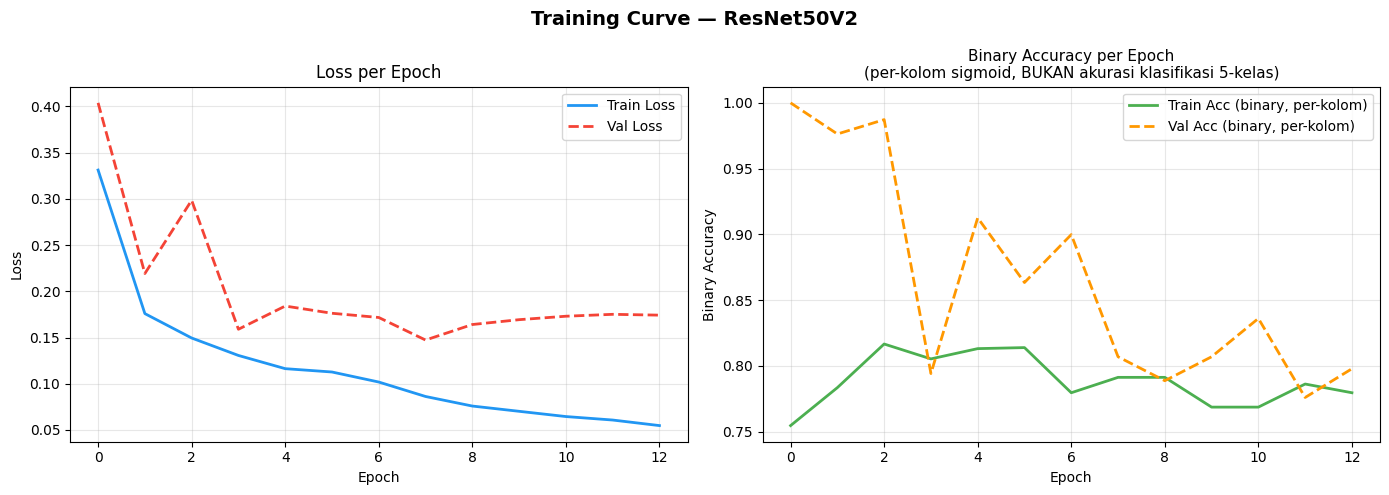


=== Evaluasi ResNet50V2 pada Test Set ===
18/18 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step
Accuracy (Test)  : 0.7782
F1-Score (Macro) : 0.5763
QWK              : 0.8793

Classification Report:
                precision    recall  f1-score   support

         No_DR       0.97      0.97      0.97       271
          Mild       0.49      0.39      0.44        56
      Moderate       0.71      0.78      0.75       150
        Severe       0.24      0.31      0.27        29
Proliferate_DR       0.53      0.41      0.46        44

      accuracy                           0.78       550
     macro avg       0.59      0.57      0.58       550
  weighted avg       0.78      0.78      0.78       550



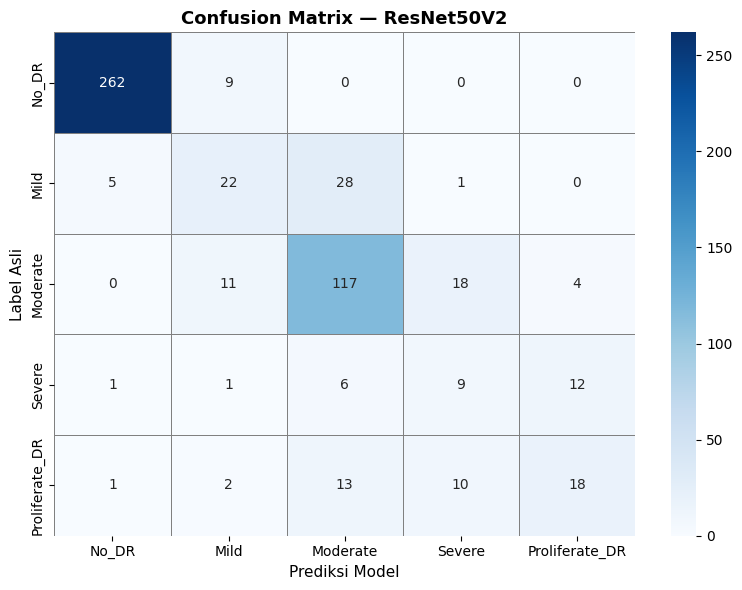

In [16]:
# Evaluasi ResNet50V2
plot_training_curve(history_res, 'ResNet50V2')
results_res = evaluate_multilabel_model(model_res, test_dataset_res, df_test, 'ResNet50V2')

# 9. Perbandingan Model

In [17]:
# ============================================================
# Tabel Perbandingan 3 Model — Multi-Label Sigmoid
# ============================================================

comparison_data = {
    'Model'   : ['EfficientNetB4', 'DenseNet121', 'ResNet50V2'],
    'Test Acc': [results_eff['accuracy'], results_dense['accuracy'], results_res['accuracy']],
    'F1-Macro': [results_eff['f1_macro'], results_dense['f1_macro'], results_res['f1_macro']],
    'QWK'     : [results_eff['qwk'],      results_dense['qwk'],      results_res['qwk']]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison_display = df_comparison.copy()
for col in ['Test Acc', 'F1-Macro', 'QWK']:
    df_comparison_display[col] = df_comparison_display[col].map('{:.4f}'.format)

print('=== Tabel Perbandingan Model (Multi-Label Sigmoid) ===')
display(df_comparison_display)

# Tentukan model terbaik berdasarkan QWK tertinggi
qwk_scores = {
    'EfficientNetB4': results_eff['qwk'],
    'DenseNet121'   : results_dense['qwk'],
    'ResNet50V2'    : results_res['qwk']
}
best_model_name = max(qwk_scores, key=qwk_scores.get)
best_qwk        = qwk_scores[best_model_name]

print(f'\n=== Model Terbaik ===')
print(f'Model    : {best_model_name}')
print(f'QWK Score: {best_qwk:.4f}')
print(f'\nNarasi: {best_model_name} dipilih sebagai model terbaik karena mencapai')
print(f'QWK (Quadratic Weighted Kappa) tertinggi sebesar {best_qwk:.4f} pada test set.')
print(f'QWK dipilih sebagai metrik utama karena label klasifikasi bersifat ordinal,')
print(f'sesuai dengan metrik utama kompetisi APTOS 2019 Blindness Detection.')

# Simpan objek model dan backbone terbaik untuk Grad-CAM
model_map = {
    'EfficientNetB4': (model_eff, backbone_eff),
    'DenseNet121'   : (model_dense, backbone_dense),
    'ResNet50V2'    : (model_res, backbone_res)
}
best_model, best_backbone = model_map[best_model_name]
print(f'\nModel {best_model_name} siap untuk Grad-CAM visualization.')

=== Tabel Perbandingan Model (Multi-Label Sigmoid) ===


,Model,Test Acc,F1-Macro,QWK
0,EfficientNetB4,0.8073,0.6298,0.8875
1,DenseNet121,0.7818,0.5846,0.8827
2,ResNet50V2,0.7782,0.5763,0.8793



=== Model Terbaik ===
Model    : EfficientNetB4
QWK Score: 0.8875

Narasi: EfficientNetB4 dipilih sebagai model terbaik karena mencapai
QWK (Quadratic Weighted Kappa) tertinggi sebesar 0.8875 pada test set.
QWK dipilih sebagai metrik utama karena label klasifikasi bersifat ordinal,
sesuai dengan metrik utama kompetisi APTOS 2019 Blindness Detection.

Model EfficientNetB4 siap untuk Grad-CAM visualization.


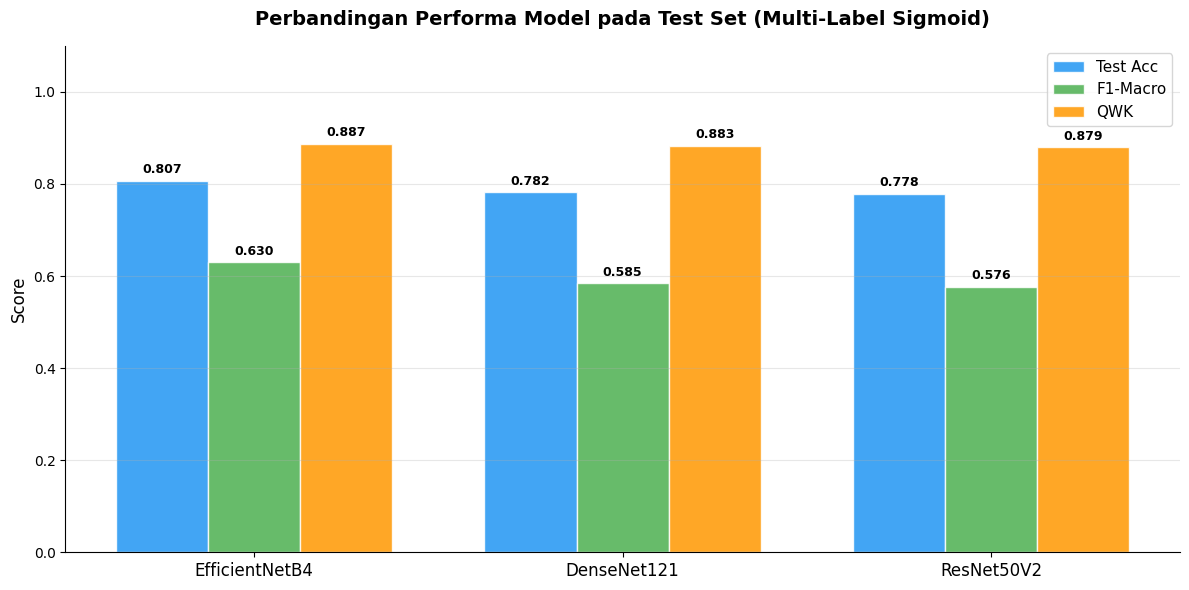

In [18]:
# ============================================================
# Visualisasi Perbandingan Model — Bar Chart
# ============================================================

model_names   = ['EfficientNetB4', 'DenseNet121', 'ResNet50V2']
metrics_names = ['Test Acc', 'F1-Macro', 'QWK']
metrics_vals  = [
    [results_eff['accuracy'], results_dense['accuracy'], results_res['accuracy']],
    [results_eff['f1_macro'], results_dense['f1_macro'], results_res['f1_macro']],
    [results_eff['qwk'],      results_dense['qwk'],      results_res['qwk']]
]

x     = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
colors  = ['#2196F3', '#4CAF50', '#FF9800']

for i, (metric, vals, color) in enumerate(zip(metrics_names, metrics_vals, colors)):
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

ax.set_title('Perbandingan Performa Model pada Test Set (Multi-Label Sigmoid)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. Grad-CAM Visualization

In [19]:
# ============================================================
# Fungsi Grad-CAM (kompatibel dengan struktur preprocess_input + sub-model backbone)
# ============================================================
# Pendekatan: karena model = Input -> preprocess_input -> backbone(sub-model) -> head,
# grad_model dibangun dengan memisahkan backbone dan head, lalu menyambungkan
# keduanya secara manual di dalam GradientTape -- ini menghindari masalah graph
# yang terputus karena sub-model dipanggil di dalam Functional API model utama.

def get_last_conv_layer_name(backbone):
    """Temukan nama layer konvolusi terakhir dari backbone."""
    for layer in reversed(backbone.layers):
        if 'conv' in layer.__class__.__name__.lower():
            return layer.name
    for layer in reversed(backbone.layers):
        try:
            if len(layer.output_shape) == 4:
                return layer.name
        except Exception:
            continue
    raise ValueError('Tidak ada layer konvolusi ditemukan di backbone!')


def build_gradcam_components(full_model, backbone, last_conv_layer_name):
    """
    Pisahkan full_model menjadi: backbone_grad (2 output: conv_terakhir, backbone_output),
    preprocess_layers (layer sebelum backbone), dan head_layers (layer setelah backbone).
    """
    backbone_grad = tf.keras.models.Model(
        inputs  = backbone.input,
        outputs = [backbone.get_layer(last_conv_layer_name).output, backbone.output],
        name='backbone_grad'
    )

    head_layers = []
    found_backbone = False
    for layer in full_model.layers:
        if layer is backbone:
            found_backbone = True
            continue
        if found_backbone:
            head_layers.append(layer)

    preprocess_layers = []
    for layer in full_model.layers:
        if layer is backbone:
            break
        if layer is not full_model.layers[0]:  # skip Input layer
            preprocess_layers.append(layer)

    return backbone_grad, preprocess_layers, head_layers


def make_gradcam_heatmap(img_array, full_model, backbone, last_conv_layer_name):
    """Hitung heatmap Grad-CAM untuk satu gambar."""
    backbone_grad, preprocess_layers, head_layers = build_gradcam_components(
        full_model, backbone, last_conv_layer_name
    )

    inputs = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        x = inputs
        for layer in preprocess_layers:
            x = layer(x)

        conv_output, backbone_output = backbone_grad(x, training=False)
        tape.watch(conv_output)

        y = backbone_output
        for layer in head_layers:
            y = layer(y, training=False)

        predictions = y
        # Untuk multi-label sigmoid, gunakan kelas dengan confidence tertinggi
        # setelah konversi cumulative (jumlah sigmoid >= 0.5)
        pred_label    = int(np.clip((predictions.numpy()[0] >= 0.5).sum() - 1, 0, NUM_CLASSES - 1))
        class_channel = predictions[:, pred_label]

    grads        = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_output[0]
    heatmap  = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    confidence = float(predictions.numpy()[0][pred_label])
    return heatmap, pred_label, confidence


def overlay_gradcam(img_original_0_255, heatmap, alpha=0.4):
    """Overlay heatmap Grad-CAM pada gambar asli (skala [0, 255])."""
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    img_uint8    = np.uint8(np.clip(img_original_0_255, 0, 255))
    superimposed = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed


print(f'Model terbaik: {best_model_name}')
print(f'Total layer backbone: {len(best_backbone.layers)}')
print('\n5 layer terakhir backbone:')
for layer in best_backbone.layers[-5:]:
    print(f'  {layer.name:50s} | {layer.__class__.__name__}')

last_conv_name = get_last_conv_layer_name(best_backbone)
print(f'\nLayer target Grad-CAM: {last_conv_name}')

Model terbaik: EfficientNetB4
Total layer backbone: 475

5 layer terakhir backbone:
  block7b_drop                                       | Dropout
  block7b_add                                        | Add
  top_conv                                           | Conv2D
  top_bn                                             | BatchNormalization
  top_activation                                     | Activation

Layer target Grad-CAM: top_conv


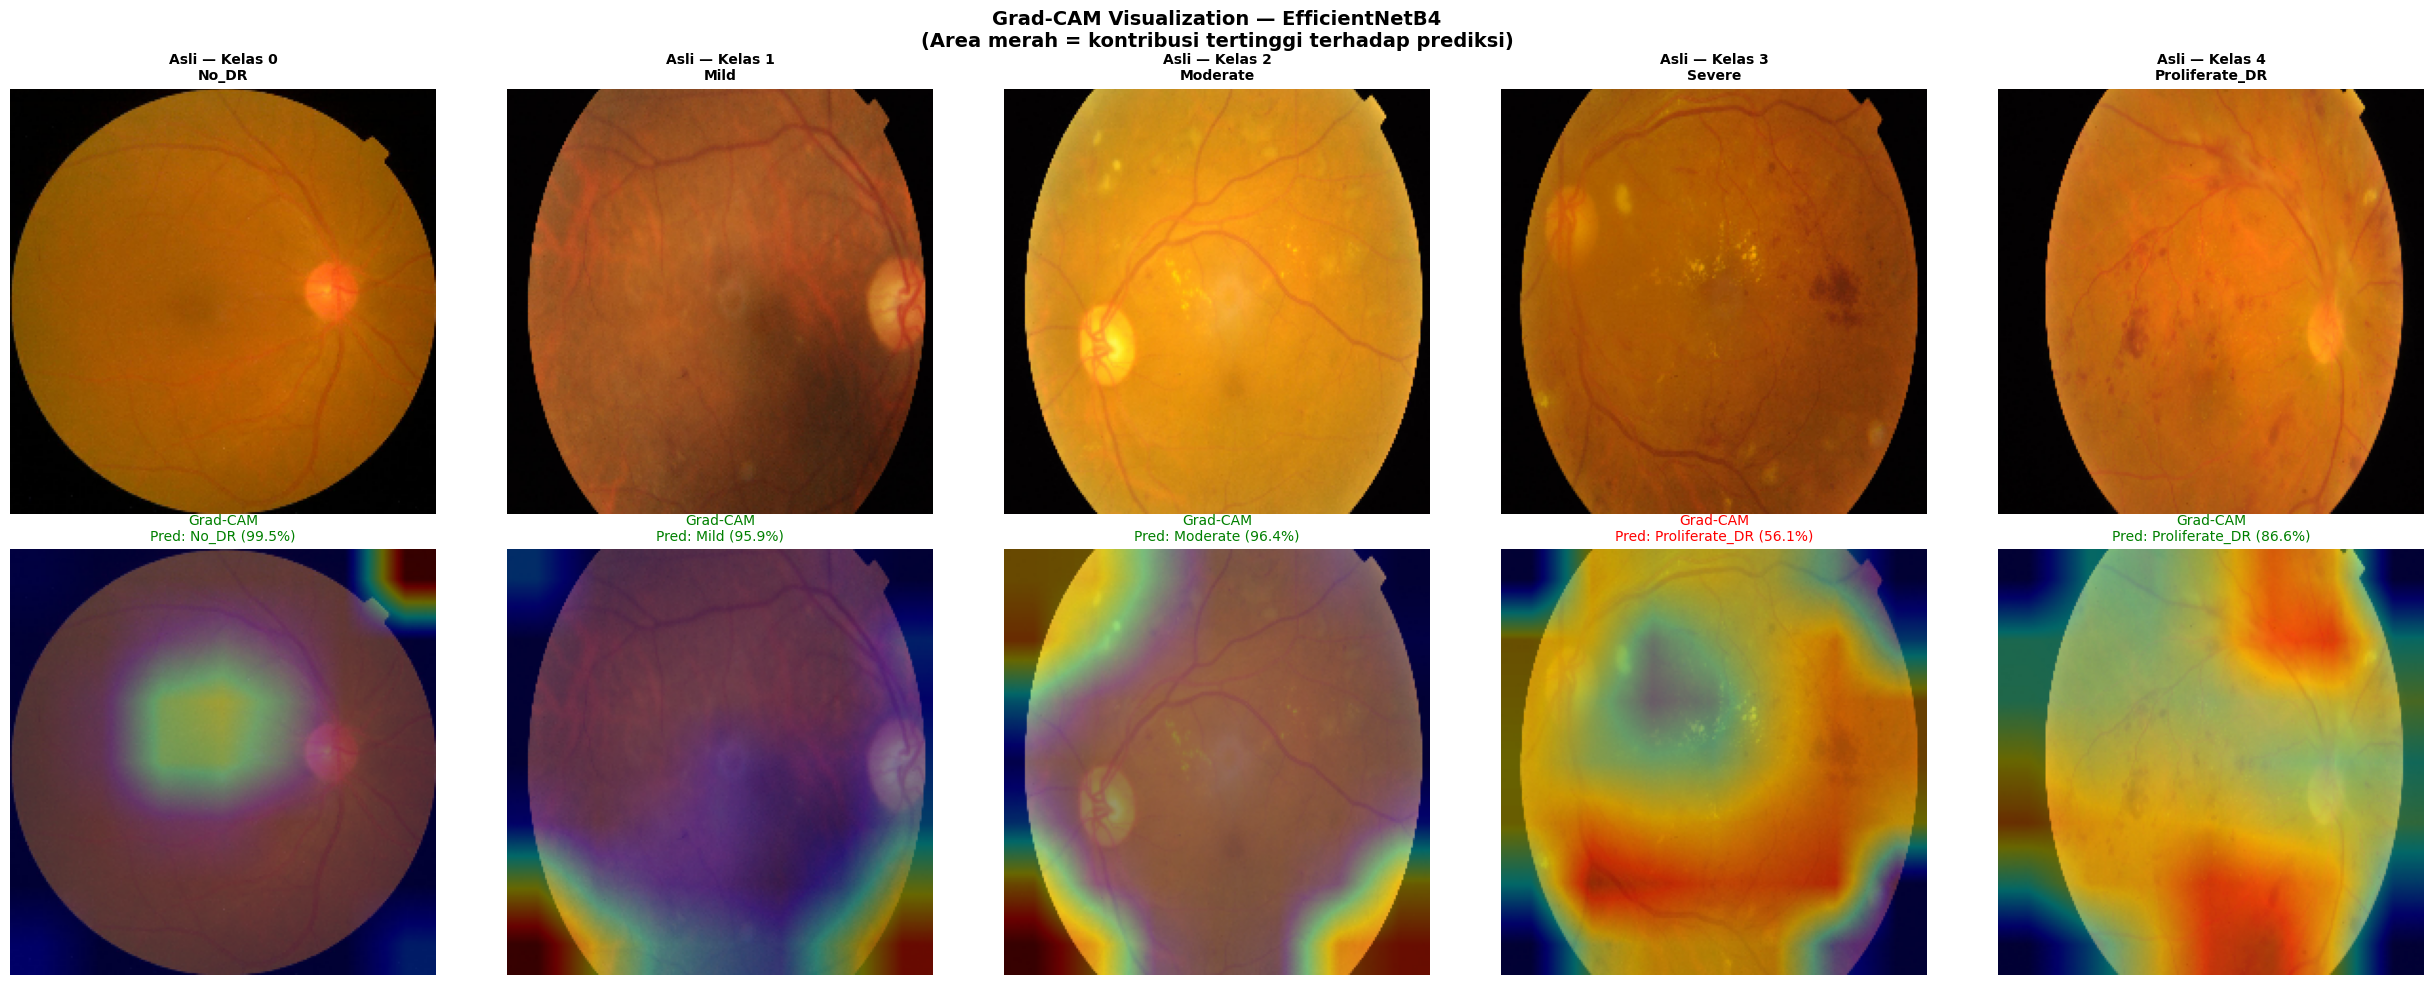


Grad-CAM berhasil divisualisasikan!
Warna merah/kuning = area retina yang paling berkontribusi pada prediksi model.
Ini berguna untuk interpretabilitas klinis (dokter/perawat bisa melihat area yang diperhatikan AI).


In [20]:
# ============================================================
# Visualisasi Grad-CAM — 5 Gambar (1 per Kelas)
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle(
    f'Grad-CAM Visualization — {best_model_name}\n'
    f'(Area merah = kontribusi tertinggi terhadap prediksi)',
    fontsize=14, fontweight='bold'
)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    samples_cls = df_test[df_test['diagnosis'] == cls_idx]
    if len(samples_cls) == 0:
        samples_cls = df[df['diagnosis'] == cls_idx]

    sample_path = samples_cls.iloc[0]['filepath']

    img_processed = load_and_preprocess(sample_path)           # skala [0, 255]
    img_batch     = np.expand_dims(img_processed, axis=0)

    heatmap, pred_idx, confidence = make_gradcam_heatmap(
        img_batch, best_model, best_backbone, last_conv_name
    )

    overlay = overlay_gradcam(img_processed, heatmap, alpha=0.4)

    axes[0, cls_idx].imshow(img_processed.astype(np.uint8))
    axes[0, cls_idx].set_title(f'Asli — Kelas {cls_idx}\n{cls_name}', fontsize=10, fontweight='bold')
    axes[0, cls_idx].axis('off')

    axes[1, cls_idx].imshow(overlay)
    axes[1, cls_idx].set_title(
        f'Grad-CAM\nPred: {CLASS_NAMES[pred_idx]} ({confidence:.1%})',
        fontsize=10,
        color='green' if pred_idx == cls_idx else 'red'
    )
    axes[1, cls_idx].axis('off')

plt.tight_layout()
plt.savefig(f'gradcam_{best_model_name.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGrad-CAM berhasil divisualisasikan!')
print('Warna merah/kuning = area retina yang paling berkontribusi pada prediksi model.')
print('Ini berguna untuk interpretabilitas klinis (dokter/perawat bisa melihat area yang diperhatikan AI).')

# 11. Kesimpulan

In [21]:
# ============================================================
# Ringkasan dan Kesimpulan
# ============================================================

print('=' * 70)
print('KESIMPULAN — RetinaCheck: Deteksi Dini Retinopati Diabetik')
print('=' * 70)

print('''
1. KONTEKS PROYEK
   RetinaCheck adalah sistem AI untuk deteksi dini Retinopati Diabetik (DR)
   berbasis Transfer Learning, dirancang untuk dioperasikan di Puskesmas oleh
   perawat menggunakan kamera fundus portabel.

2. DATASET
   - Dataset APTOS 2019: 3.662 gambar retina berlabel (5 kelas)
   - Dataset sangat imbalanced: kelas No_DR mendominasi (~49%)

3. METODOLOGI KUNCI
   - Preprocessing: resize saja (TANPA CLAHE -- terbukti tidak membantu pretrained backbone)
   - Strategi label: Multi-Label Cumulative Sigmoid (ordinal-aware), BUKAN softmax biasa
     -> Label diagnosis 0-4 di-encode sebagai representasi cumulative (mis. label 3 -> [1,1,1,1,0])
     -> Loss: binary_crossentropy, output: 5 unit sigmoid
   - Backbone: TIDAK di-freeze, langsung fine-tune total dari awal dengan LR kecil (5e-5)
   - Augmentasi: flip horizontal+vertikal, zoom +-15% (TANPA rotasi ekstrem)
   - Metrik utama: QWK (Quadratic Weighted Kappa) -- sesuai metrik resmi kompetisi APTOS 2019

4. PERTIMBANGAN METODOLOGIS PENTING
   Pendekatan multi-label sigmoid dipilih setelah perbandingan empiris menunjukkan
   pendekatan ini secara konsisten mengungguli softmax 5-kelas independen,
   khususnya pada kelas-kelas ordinal yang saling bertetangga (Moderate-Severe-
   Proliferate_DR). Eksperimen tambahan (sample weighting, threshold optimization,
   ensemble) telah dicoba namun tidak terbukti memberikan perbaikan konsisten
   dibanding pendekatan dasar tanpa pembobotan tambahan.
''')

print('5. RINGKASAN PERFORMA MODEL')
print('-' * 60)
print(f'  {"Model":<18} {"Test Acc":>10} {"F1-Macro":>10} {"QWK":>10}')
print('-' * 60)
for r in [results_eff, results_dense, results_res]:
    marker = ' <- TERBAIK' if r['model_name'] == best_model_name else ''
    print(f'  {r["model_name"]:<18} {r["accuracy"]:>10.4f} {r["f1_macro"]:>10.4f} {r["qwk"]:>10.4f}{marker}')
print('-' * 60)

print(f'''
6. KESIMPULAN UTAMA
   - Model terbaik: {best_model_name} dengan QWK = {best_qwk:.4f}
   - Grad-CAM membuktikan model memfokuskan perhatian pada area lesi retina
     yang relevan secara klinis (mikroaneurisma, perdarahan, eksudat)
   - Sistem ini berpotensi membantu skrining DR di fasilitas kesehatan
     primer Indonesia, mengurangi keterlambatan diagnosis dan risiko kebutaan

7. KETERBATASAN & REKOMENDASI LANJUTAN
   - Kelas minoritas (Severe, Proliferate_DR) masih menjadi titik lemah utama,
     dengan tingkat saling tertukar (confusion) yang signifikan antar keduanya
   - Rekomendasi pengembangan lanjutan: data tambahan untuk kelas minoritas,
     resolusi gambar lebih tinggi untuk deteksi lesi halus, atau pendekatan
     two-stage classification (ringan vs berat, lalu detail di antara yang berat)
   - Validasi lebih lanjut dengan data pasien Indonesia diperlukan sebelum deployment
''')

print('=' * 70)
print('Notebook RetinaCheck selesai dijalankan!')
print('=' * 70)

KESIMPULAN — RetinaCheck: Deteksi Dini Retinopati Diabetik

1. KONTEKS PROYEK
   RetinaCheck adalah sistem AI untuk deteksi dini Retinopati Diabetik (DR)
   berbasis Transfer Learning, dirancang untuk dioperasikan di Puskesmas oleh
   perawat menggunakan kamera fundus portabel.

2. DATASET
   - Dataset APTOS 2019: 3.662 gambar retina berlabel (5 kelas)
   - Dataset sangat imbalanced: kelas No_DR mendominasi (~49%)

3. METODOLOGI KUNCI
   - Preprocessing: resize saja (TANPA CLAHE -- terbukti tidak membantu pretrained backbone)
   - Strategi label: Multi-Label Cumulative Sigmoid (ordinal-aware), BUKAN softmax biasa
     -> Label diagnosis 0-4 di-encode sebagai representasi cumulative (mis. label 3 -> [1,1,1,1,0])
     -> Loss: binary_crossentropy, output: 5 unit sigmoid
   - Backbone: TIDAK di-freeze, langsung fine-tune total dari awal dengan LR kecil (5e-5)
   - Augmentasi: flip horizontal+vertikal, zoom +-15% (TANPA rotasi ekstrem)
   - Metrik utama: QWK (Quadratic Weighted Kappa) -- s

# 12. Eksperimen

In [22]:
%%script false --no-raise-error
# ============================================================
# EKSPERIMEN BESAR — Replikasi Strategi Paper (Chilukoti et al., 2024)
# ============================================================
# Kombinasi 5 elemen dari paper yang terbukti menaikkan QWK:
#   1. EfficientNetB3 (bukan B0/B4 — "compound scaling paling pas" menurut paper)
#   2. Head classifier 3-layer (1536->512->512->5) dengan SOFTMAX (bukan sigmoid)
#   3. Adam LR=0.001 + gradient clipping (bukan 5e-5 seperti setup kita sebelumnya)
#   4. CLAHE + Gaussian Blur kombinasi (bukan CLAHE sendirian)
#   5. Training panjang (60 epoch) dengan checkpoint di beberapa titik untuk ensemble

print('='*60)
print('EKSPERIMEN: EfficientNetB3 — Replikasi Strategi Paper')
print('='*60)

from tensorflow.keras.applications import EfficientNetB3

tf.keras.backend.clear_session()

# ------------------------------------------------------------
# 1. Preprocessing — CLAHE + Gaussian Blur (kombinasi, sesuai paper)
# ------------------------------------------------------------
def load_and_preprocess_paper(filepath, img_size=224):
    """
    Preprocessing sesuai strategi kedua paper: CLAHE + Gaussian Blur.
    Output skala [0, 255] float32 (rescaling akhir oleh preprocess_input EfficientNet).
    """
    img = cv2.imread(str(filepath))
    if img is None:
        raise FileNotFoundError(f'Gambar tidak ditemukan: {filepath}')
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))

    # CLAHE pada channel hijau (kontras lesi retina)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    r, g, b = cv2.split(img)
    g_clahe = clahe.apply(g)
    img = cv2.merge([r, g_clahe, b])

    # Gaussian Blur ringan untuk reduksi noise (sesuai paper)
    img = cv2.GaussianBlur(img, (3, 3), 0)

    img = img.astype(np.float32)
    return img


# Verifikasi preprocessing pada satu gambar
sample_path = df_train['filepath'].iloc[0]
proc_paper = load_and_preprocess_paper(sample_path)
print(f'Shape hasil preprocessing: {proc_paper.shape}')
print(f'Range piksel: [{proc_paper.min():.1f}, {proc_paper.max():.1f}]')

plt.figure(figsize=(4, 4))
plt.imshow(proc_paper.astype(np.uint8))
plt.title('CLAHE + Gaussian Blur (strategi paper)', fontsize=11, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Data generator dengan preprocessing baru + augmentasi standar
# ------------------------------------------------------------
def create_data_generator_paper(dataframe, augment=False, batch_size=32, img_size=224):
    """Data generator dengan CLAHE+Blur, label SOFTMAX one-hot (bukan multi-label cumulative)."""
    filepaths = dataframe['filepath'].values
    labels    = dataframe['diagnosis'].values
    labels_onehot = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)

    def load_image(filepath, label):
        def _load(fp, lb):
            fp_str = fp.numpy().decode('utf-8')
            lb_np  = lb.numpy()
            img    = load_and_preprocess_paper(fp_str, img_size)
            return img, lb_np.astype(np.float32)
        img, lbl = tf.py_function(func=_load, inp=[filepath, label], Tout=[tf.float32, tf.float32])
        img.set_shape([img_size, img_size, 3])
        lbl.set_shape([NUM_CLASSES])
        return img, lbl

    def augment_image(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        zoom_factor = tf.random.uniform(shape=[], minval=0.85, maxval=1.15)
        new_size    = tf.cast(tf.cast(img_size, tf.float32) * zoom_factor, tf.int32)
        img         = tf.image.resize(img, [new_size, new_size])
        img         = tf.image.resize_with_crop_or_pad(img, img_size, img_size)
        img         = tf.clip_by_value(img, 0.0, 255.0)
        return img, label

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels_onehot))
    if augment:
        dataset = dataset.shuffle(buffer_size=len(filepaths), seed=SEED)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


train_dataset_effb3 = create_data_generator_paper(df_train, augment=True,  batch_size=32)
val_dataset_effb3   = create_data_generator_paper(df_val,   augment=False, batch_size=32)
test_dataset_effb3  = create_data_generator_paper(df_test,  augment=False, batch_size=32)

print('\nData generator (CLAHE+Blur, label softmax) siap.')

# ------------------------------------------------------------
# 3. Bangun model — EfficientNetB3 + head 3-layer (sesuai paper)
# ------------------------------------------------------------
backbone_effb3 = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
backbone_effb3.trainable = True   # fine-tune total dari awal

inputs = Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = backbone_effb3(x, training=True)
x = GlobalAveragePooling2D()(x)          # 7x7x1536 -> 1536 (adaptive avg pool, sesuai paper)

# Head 3-layer sesuai paper: FC(512) -> Dropout(0.5) -> ReLU -> FC(512) -> Dropout(0.25) -> ReLU -> FC(5) -> Softmax
x = Dense(512, activation=None)(x)
x = Dropout(0.5)(x)
x = tf.keras.layers.ReLU()(x)

x = Dense(512, activation=None)(x)
x = Dropout(0.25)(x)
x = tf.keras.layers.ReLU()(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)   # SOFTMAX, sesuai paper

model_effb3 = Model(inputs, outputs, name='EfficientNetB3_Paper')

# Optimizer dengan gradient clipping, sesuai paper (LR=0.001, clipnorm=0.1)
optimizer_paper = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=0.1, weight_decay=1e-4)

model_effb3.compile(
    optimizer=optimizer_paper,
    loss='categorical_crossentropy',   # softmax -> categorical, bukan binary
    metrics=['accuracy']
)

print(f'\nTotal parameter        : {model_effb3.count_params():,}')
print(f'Parameter dapat dilatih: {sum([tf.size(w).numpy() for w in model_effb3.trainable_variables]):,}')

# ------------------------------------------------------------
# 4. Training — checkpoint disimpan di beberapa titik (untuk ensemble nanti)
# ------------------------------------------------------------
class MultiCheckpointSaver(tf.keras.callbacks.Callback):
    """Simpan model di epoch tertentu (mis. 15, 30) untuk strategi ensemble multi-checkpoint."""
    def __init__(self, save_epochs, prefix='effb3_paper'):
        super().__init__()
        self.save_epochs = save_epochs
        self.prefix = prefix

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) in self.save_epochs:
            fname = f'{self.prefix}_epoch{epoch+1}.h5'
            self.model.save(fname)
            print(f'\n>>> Checkpoint disimpan: {fname} (epoch {epoch+1})')

callbacks_effb3 = [
    ModelCheckpoint(filepath='best_effb3_paper.h5', monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    MultiCheckpointSaver(save_epochs=[15, 30])
]

history_effb3 = model_effb3.fit(
    train_dataset_effb3,
    validation_data=val_dataset_effb3,
    epochs=30,
    callbacks=callbacks_effb3,
    verbose=1
)

print('\nTraining EfficientNetB3 (strategi paper) selesai!')

In [23]:
%%script false --no-raise-error
# ============================================================
# Evaluasi EfficientNetB3 — Strategi Paper
# ============================================================

print('=== Evaluasi EfficientNetB3_Paper pada Test Set ===')

y_pred_probs_effb3 = model_effb3.predict(test_dataset_effb3, verbose=1)
y_pred_effb3       = np.argmax(y_pred_probs_effb3, axis=1)
y_true_effb3       = df_test['diagnosis'].values[:len(y_pred_effb3)]

acc_effb3  = np.mean(y_pred_effb3 == y_true_effb3)
f1_effb3   = f1_score(y_true_effb3, y_pred_effb3, average='macro')
qwk_effb3  = cohen_kappa_score(y_true_effb3, y_pred_effb3, weights='quadratic')

print(f'Accuracy (Test)  : {acc_effb3:.4f}')
print(f'F1-Score (Macro) : {f1_effb3:.4f}')
print(f'QWK              : {qwk_effb3:.4f}')

print('\nClassification Report:')
print(classification_report(y_true_effb3, y_pred_effb3, target_names=CLASS_NAMES))

cm_effb3 = confusion_matrix(y_true_effb3, y_pred_effb3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_effb3, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — EfficientNetB3 (Strategi Paper)', fontsize=13, fontweight='bold')
plt.ylabel('Label Asli'); plt.xlabel('Prediksi Model')
plt.tight_layout()
plt.savefig('cm_effb3_paper.png', dpi=150, bbox_inches='tight')
plt.show()